# LangChain 核心模块学习：Memory

大多数LLM应用都具有对话界面。对话的一个重要组成部分是能够引用先前在对话中介绍过的信息。至少，一个对话系统应该能够直接访问一些过去消息的窗口。更复杂的系统将需要拥有一个不断更新的世界模型，使其能够保持关于实体及其关系的信息。

我们将存储过去交互信息的能力称为“记忆（Memory）”。

LangChain提供了许多用于向应用/系统中添加 Memory 的实用工具。这些工具可以单独使用，也可以无缝地集成到链中。

一个记忆系统（Memory System）需要支持两个基本操作：**读取（READ）和写入（WRITE）**。

每个链都定义了一些核心执行逻辑，并期望某些输入。其中一些输入直接来自用户，但有些输入可能来自 Memory。

在一个典型 Chain 的单次运行中，将与其 Memory System 进行至少两次交互:

1. 在接收到初始用户输入之后，在执行核心逻辑之前，链将从其 Memory 中**读取**并扩充用户输入。
2. 在执行核心逻辑之后但在返回答案之前，一个链条将把当前运行的输入和输出**写入** Memory ，以便在未来的运行中可以引用它们。
3. 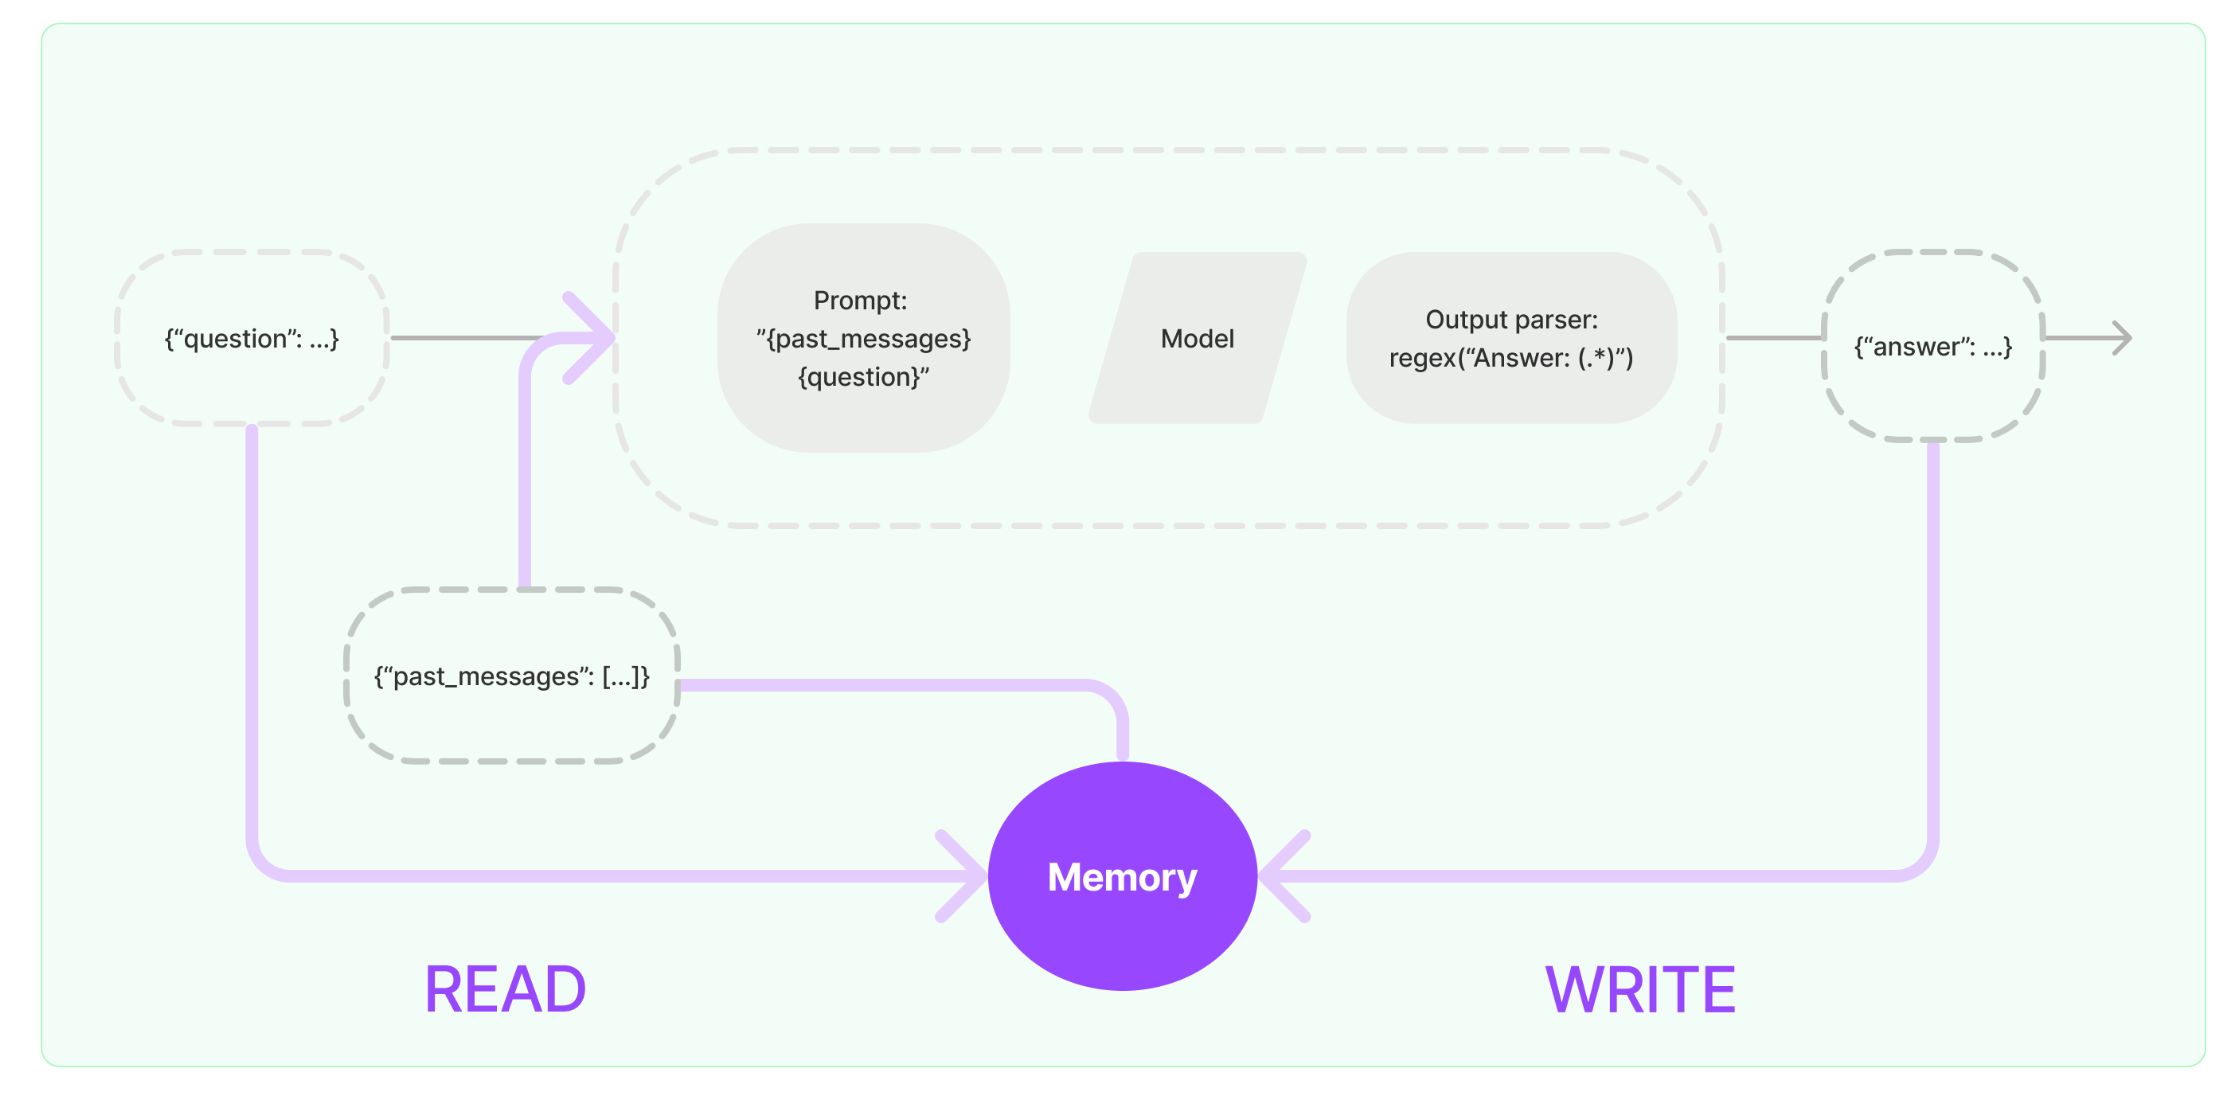


## BaseMemory Class 基类

BaseMemory = LangChain 记忆模块的「统一接口标准」= 所有记忆类必须遵守的规矩
【新版（v1.0+）已弃用旧 Memory 体系。旧版 Memory（BaseMemory → BaseChatMemory → xxxMemory）是 v0.x 时代的设计】
【新版：BaseChatMessageHistory + RunnableWithMessageHistory + LangGraph Checkpointer】


类继承关系：

```
## 适用于简单的语言模型
BaseMemory：最顶层规矩
   ↑
BaseChatMemory：针对聊天场景的扩展
   ↑
各种具体记忆（Buffer、Window、Summary、Redis、Zep...）

```
从 langchain.memory 里移除了搬到了兼容包：langchain_classic.memory

```python
# 定义一个名为BaseMemory的基础类
class BaseMemory(Serializable, ABC):
    """用于Chains中的内存的抽象基类。
    
    这里的内存指的是Chains中的状态。内存可以用来存储关于Chain的过去执行的信息，
    并将该信息注入到Chain的未来执行的输入中。例如，对于会话型Chains，内存可以用来
    存储会话，并自动将它们添加到未来的模型提示中，以便模型具有必要的上下文来连贯地
    响应最新的输入。"""

    # 定义一个名为Config的子类
    class Config:
        """为此pydantic对象配置。
    
        Pydantic是一个Python库，用于数据验证和设置管理，主要基于Python类型提示。
        """
    
        # 允许在pydantic模型中使用任意类型。这通常用于允许复杂的数据类型。
        arbitrary_types_allowed = True
    
    # 下面是一些必须由子类实现的方法：
    
    # 定义一个属性，它是一个抽象方法。任何从BaseMemory派生的子类都需要实现此方法。
    # 此方法应返回该内存类将添加到链输入的字符串键。
    @property
    @abstractmethod
    def memory_variables(self) -> List[str]:
        """获取此内存类将添加到链输入的字符串键。"""
    
    # 定义一个抽象方法。任何从BaseMemory派生的子类都需要实现此方法。
    # 此方法基于给定的链输入返回键值对。
    @abstractmethod
    def load_memory_variables(self, inputs: Dict[str, Any]) -> Dict[str, Any]:
        """根据给链的文本输入返回键值对。"""
    
    # 定义一个抽象方法。任何从BaseMemory派生的子类都需要实现此方法。
    # 此方法将此链运行的上下文保存到内存。
    @abstractmethod
    def save_context(self, inputs: Dict[str, Any], outputs: Dict[str, str]) -> None:
        """保存此链运行的上下文到内存。"""
    
    # 定义一个抽象方法。任何从BaseMemory派生的子类都需要实现此方法。
    # 此方法清除内存内容。
    @abstractmethod
    def clear(self) -> None:
        """清除内存内容。"""
```

## BaseChatMessageHistory Class 基类

结构关系：

BaseMemory：最顶层，给链用的 “记忆接口”（load/save/clear）。
   ↑
BaseChatMemory  （使用）：中间层，继承 BaseMemory，内部持有 chat_memory（BaseChatMessageHistory），负责把消息转成链能用的格式。
   ↑
BaseChatMessageHistory （存消息）：最底层，只存消息列表（HumanMessage/AIMessage），只管增删查消息。

类继承关系：

```
## 适用于聊天模型

BaseChatMessageHistory --> <name>ChatMessageHistory  # Example: ZepChatMessageHistory
```

```python
# 定义一个名为BaseChatMessageHistory的基础类
class BaseChatMessageHistory(ABC):
    """聊天消息历史记录的抽象基类。"""

    # 在内存中存储的消息列表
    messages: List[BaseMessage]

    # 定义一个add_user_message方法，它是一个方便的方法，用于将人类消息字符串添加到存储区。
    def add_user_message(self, message: str) -> None:
        """为存储添加一个人类消息字符串的便捷方法。

        参数:
            message: 人类消息的字符串内容。
        """
        self.add_message(HumanMessage(content=message))

    # 定义一个add_ai_message方法，它是一个方便的方法，用于将AI消息字符串添加到存储区。
    def add_ai_message(self, message: str) -> None:
        """为存储添加一个AI消息字符串的便捷方法。

        参数:
            message: AI消息的字符串内容。
        """
        self.add_message(AIMessage(content=message))

    # 抽象方法，需要由继承此基类的子类来实现。
    @abstractmethod
    def add_message(self, message: BaseMessage) -> None:
        """将Message对象添加到存储区。

        参数:
            message: 要存储的BaseMessage对象。
        """
        raise NotImplementedError()

    # 抽象方法，需要由继承此基类的子类来实现。
    @abstractmethod
    def clear(self) -> None:
        """从存储中删除所有消息"""

```

In [2]:
# 新版langchain 必须从 classic 导入，直接langchain.memory找不到
from langchain.memory import ConversationBufferMemory
from langchain.chains import ConversationChain
from langchain_community.chat_models import ChatZhipuAI        # 智谱模型

import os
from dotenv import load_dotenv
load_dotenv()


# ======================  初始化 智谱模型 ======================
llm = ChatZhipuAI(model="glm-4.5-air", api_key=os.getenv("ZHIPUAI_API_KEY"), temperature=0.3)

# 初始化全量缓存记忆
memory = ConversationBufferMemory()

# 绑定对话链
conv_chain = ConversationChain(llm=llm, memory=memory, verbose=True)

# 多轮对话
print(conv_chain.predict(input="我想学Python"))
print(conv_chain.predict(input="帮我写个循环"))

# 清空记忆
memory.clear()

/var/folders/5y/kn_pcqq52hz14rd2rchcpkq80000gn/T/ipykernel_32886/1110895105.py:15: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory()
/var/folders/5y/kn_pcqq52hz14rd2rchcpkq80000gn/T/ipykernel_32886/1110895105.py:18: LangChainDeprecationWarning: The class `ConversationChain` was deprecated in LangChain 0.2.7 and will be removed in 1.0. Use :meth:`~RunnableWithMessageHistory: https://python.langchain.com/v0.2/api_reference/core/runnables/langchain_core.runnables.history.RunnableWithMessageHistory.html` instead.
  conv_chain = ConversationChain(llm=llm, memory=memory, verbose=True)




> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from its context. If the AI does not know the answer to a question, it truthfully says it does not know.

Current conversation:

Human: 我想学Python
AI:

> Finished chain.
你好！很高兴你想学习Python！Python是一门非常强大且受欢迎的编程语言，特别适合初学者。

Python的应用非常广泛，包括：
- 数据分析和科学计算（使用NumPy、Pandas等库）
- 人工智能和机器学习（TensorFlow、PyTorch）
- 网站开发（Django、Flask框架）
- 自动化脚本编写
- 游戏开发
- 自然语言处理

对于初学者，我建议你从以下几个方面开始：
1. 先掌握Python基础语法（变量、数据类型、控制流、函数等）
2. 学习使用Jupyter Notebook进行交互式编程
3. 练习解决小问题，比如编写简单的计算器、猜数字游戏等
4. 逐步学习面向对象编程概念

有很多优秀的学习资源，如Python官方教程、《Python Crash Course》书籍、Codecademy、Coursera上的课程等。

你有什么特定的Python应用方向感兴趣吗？或者你目前编程经验如何？这样我可以给你更具体的建议。


> Entering new ConversationChain chain...
Prompt after formatting:
The following is a friendly conversation between a human and an AI. The AI is talkative and provides lots of specific details from i